In [ ]:
!pip install neurokit2


In [ ]:
!pip install wfdb

In [ ]:
!pip install antropy

In [ ]:
import urllib.request
import os

# The base URL for the PhysioNet Brugada dataset (version 1.0.0)
base_url = "https://physionet.org/files/brugada-huca/1.0.0/"

# The specific extra files you want to download
files_to_download = [
    "metadata.csv",
    "metadata_dictionary.csv",
    "README.md",
    "LICENSE.txt",
    "SHA256SUMS.txt"
]

# The folder where you want to save them
save_dir = "./brugada-huca"

# Ensure the folder exists
os.makedirs(save_dir, exist_ok=True)

for file in files_to_download:
    file_url = base_url + file
    save_path = os.path.join(save_dir, file)
    
    print(f"Downloading {file}...")
    try:
        urllib.request.urlretrieve(file_url, save_path)
        print(f"Successfully downloaded {file}")
    except Exception as e:
        print(f"Failed to download {file}: {e}")


In [ ]:
import wfdb

# This will download the entire brugada-huca dataset recursively into a folder
wfdb.dl_database('brugada-huca', dl_dir='./brugada-huca')


In [1]:
import os

# Create the folder if it doesn't exist
os.makedirs('./brugada-huca', exist_ok=True)

# Change the notebook's current working directory to that folder
os.chdir('./brugada-huca')

# Verify that you are now inside the folder
print("Current Working Directory:", os.getcwd())


Current Working Directory: c:\Users\User\OneDrive\Documents\idsc_2026\brugada-huca


In [2]:
import pandas as pd

# Load metadata
metadata = pd.read_csv('metadata.csv')

# Display basic statistics
print(metadata.head())
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


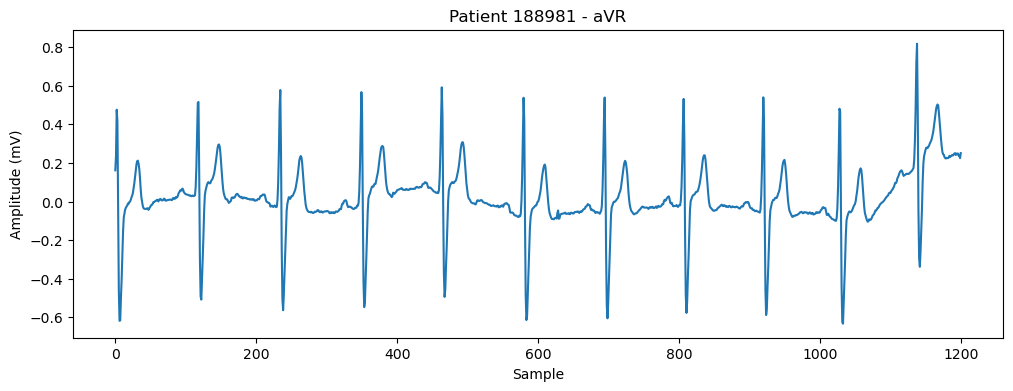

In [3]:
import wfdb
import matplotlib.pyplot as plt

# Read a single patient's ECG
patient_id = '188981'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

# Access the signal data
signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

# Plot a specific lead
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 4])  # Plot first lead (Lead I)
plt.title(f'Patient {patient_id} - {lead_names[3]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

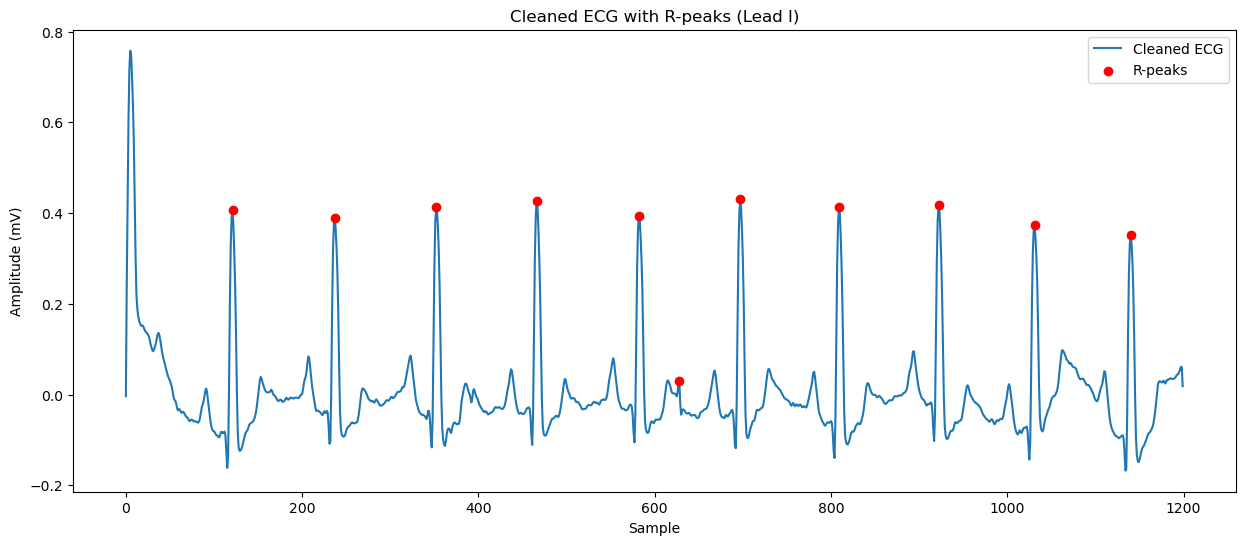

In [4]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# We use the signal from the previous cell
ecg_signal = signals[:, 1] # Lead I

# 1. Clean the signal (High-pass, low-pass, powerline)
# The "neurokit" method applies a 0.5Hz high-pass filter and a 50Hz powerline notch filter
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_freq, method="neurokit")

# 2. Find R-peaks
_, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_freq)

# 3. Delineate PQST waves
_, waves_peak = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_freq, method="peak")

# 4. Plot the cleaned signal and the peaks for the first 5 seconds
plot_limit = sampling_freq * 12# first 5 seconds

plt.figure(figsize=(15, 6))
plt.plot(ecg_cleaned[:plot_limit], label='Cleaned ECG')

# highlight R-peaks
valid_rpeaks = [p for p in rpeaks['ECG_R_Peaks'] if p < plot_limit]
plt.scatter(valid_rpeaks, ecg_cleaned[valid_rpeaks], color='red', label='R-peaks', zorder=5)

plt.title('Cleaned ECG with R-peaks (Lead I)')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


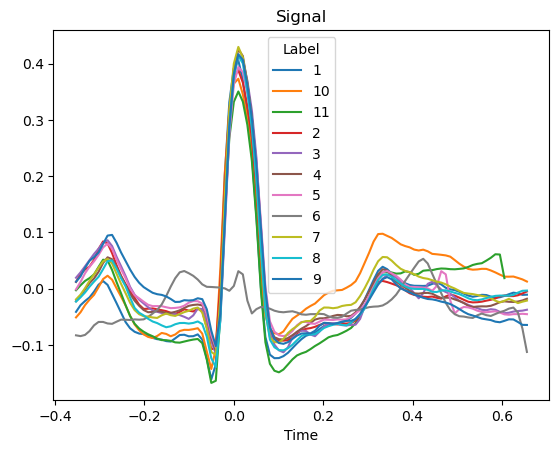

In [5]:
# 5. Create a composite (median) representation of the heartbeat
ecg_epochs = nk.ecg_segment(ecg_cleaned, rpeaks=rpeaks['ECG_R_Peaks'], sampling_rate=sampling_freq)

# Plot all heartbeats and the median
nk.epochs_plot(ecg_epochs)
plt.show()


In [6]:
import sys
sys.path.append('..') 

from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi


In [7]:
from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi

# Run on a single patient
res = process_patient(signals[:, 0], fs=100, window_sec =0.9, step_sec =0.5)
print("Standard Entropies and ERSI:", res)

tsallis_res = process_patient_tsallis(signals[:, 0], fs=1000,window_sec =0.9, step_sec =0.5)
print("Tsallis ERSI:", tsallis_res)


Standard Entropies and ERSI: {'shannon': 1.8379180891356948, 'app_entropy': 0.20658947908803643, 'sample_entropy': 0.15059198420781444, 'perm_entropy': 1.7983804563685553, 'spectral_entropy': nan, 'svd_entropy': 1.0692093659055493, 'shannon_ERSI': 0.2612344112785552, 'app_entropy_ERSI': 0.026996150565677102, 'sample_entropy_ERSI': 0.019428629058352975, 'perm_entropy_ERSI': 0.2669219522435844, 'spectral_entropy_ERSI': nan, 'svd_entropy_ERSI': 0.1462674821710679, 'ERSI_timeseries': 0.7208486253172377, 'ERSI_full': 0.04223585810996282}
Tsallis ERSI: 0.8430913580246914


In [8]:
# Run benchmark across two subsets
# First, load the metadata to find which patients are Healthy (Normal) vs Brugada
import pandas as pd
import wfdb
import os
metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []


In [9]:
# For demonstration, limit to 5 per group to save time
for pid in healthy_patients[:5]:
    try:
        # wfdb rdrecord reads the .dat files inside the nested folders
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Append Lead 0
        healthy_group.append(record.p_signal[:, 0])
    except:
        continue
for pid in brugada_patients[:5]:
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        brugada_group.append(record.p_signal[:, 0])
    except:
        continue
# The new default window_sec=5.0 requires signals to be at least 5000 points long (at fs=1000).
p_values = benchmark_ersi(healthy_group, brugada_group,  fs=100, window_sec=5.0, step_sec=2.5)

Processing 5 healthy signals...
Processing 5 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
shannon                  0.420635
app_entropy_ERSI         0.547619
sample_entropy_ERSI      0.547619
app_entropy              0.690476
perm_entropy             0.690476
perm_entropy_ERSI        0.690476
svd_entropy              0.841270
shannon_ERSI             0.841270
svd_entropy_ERSI         0.841270
sample_entropy           1.000000
ERSI_timeseries          1.000000
ERSI_full                1.000000
tsallis_ERSI             1.000000
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64


In [10]:
import pandas as pd
import wfdb
import os

metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []

# Target Lead V1 or V2 where Brugada abnormalities manifest
target_lead = 'V1' 
limit = 50  # Increase sample size to get true statistical power!

print("Extracting Healthy patients...")
for pid in healthy_patients:
    if len(healthy_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Find the index of our target lead dynamically
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        healthy_group.append(record.p_signal[:, lead_idx])
    except:
        continue

print("Extracting Brugada patients...")
for pid in brugada_patients:
    if len(brugada_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        brugada_group.append(record.p_signal[:, lead_idx])
    except:
        continue

p_values = benchmark_ersi(healthy_group, brugada_group, fs=100, window_sec=5.0, step_sec=2.5)


Extracting Healthy patients...
Extracting Brugada patients...
Processing 50 healthy signals...
Processing 50 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
svd_entropy              0.000058
svd_entropy_ERSI         0.000069
shannon                  0.000492
sample_entropy           0.000518
sample_entropy_ERSI      0.000703
shannon_ERSI             0.000859
tsallis_ERSI             0.002620
ERSI_full                0.009257
ERSI_timeseries          0.013457
app_entropy              0.061251
app_entropy_ERSI         0.073623
perm_entropy_ERSI        0.115200
perm_entropy             0.125059
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64


In [11]:
# Import the function from our new script
from ecg_pipeline_features import process_single_lead

# Optional: To see pandas DataFrames clearly in Jupyter
import pandas as pd
pd.set_option('display.max_columns', None)

# Select Lead I (which is index 0 in your WFDB arrays)
# If you want a different lead, just change the index 0 to whichever lead you need.
lead_0_signal = signals[:, 0]

# Run the pipeline to get the features dataframe
features_df = process_single_lead(ecg_signal=lead_0_signal, sampling_rate=sampling_freq)

# Display the first few beats
display(features_df.head())


,beat_index,period_s,QRS_duration_s,ST_segment_s,has_U_wave,T_wave_inversion,TimeGap_P_Q_s,VoltDiff_P_Q,TimeGap_P_R_s,VoltDiff_P_R,TimeGap_P_S_s,VoltDiff_P_S,TimeGap_P_T_s,VoltDiff_P_T,TimeGap_Q_R_s,VoltDiff_Q_R,TimeGap_Q_S_s,VoltDiff_Q_S,TimeGap_Q_T_s,VoltDiff_Q_T,TimeGap_R_S_s,VoltDiff_R_S,TimeGap_R_T_s,VoltDiff_R_T,TimeGap_S_T_s,VoltDiff_S_T
0,0,1.16,0.17,0.13,False,False,0.20,-0.08375,0.27,0.44700,0.31,-0.37225,0.55,0.17325,0.07,0.53075,0.11,-0.28850,0.35,0.25700,0.04,-0.81925,0.28,-0.27375,0.24,0.54550
1,1,1.15,0.26,0.12,False,False,0.16,-0.09975,0.27,0.52850,0.31,-0.38000,0.56,0.19550,0.11,0.62825,0.15,-0.28025,0.40,0.29525,0.04,-0.90850,0.29,-0.33300,0.25,0.57550
2,2,1.14,0.34,0.12,False,False,0.18,-0.11300,0.26,0.48225,0.31,-0.38325,0.55,0.14875,0.08,0.59525,0.13,-0.27025,0.37,0.26175,0.05,-0.86550,0.29,-0.33350,0.24,0.53200
3,3,1.16,0.26,0.12,False,False,0.15,-0.08475,0.25,0.47350,0.30,-0.35725,0.54,0.20550,0.10,0.55825,0.15,-0.27250,0.39,0.29025,0.05,-0.83075,0.29,-0.26800,0.24,0.56275
4,4,1.15,0.26,0.12,False,False,0.17,-0.10925,0.26,0.50400,0.31,-0.40600,0.56,0.16150,0.09,0.61325,0.14,-0.29675,0.39,0.27075,0.05,-0.91000,0.30,-0.34250,0.25,0.56750


Loading metadata...
Found 287 healthy patients, 69 Brugada patients

Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
V1 index: 6
Sampling frequency: 100 Hz

Loading ECG signals (Lead V1, index 6)...
Loading healthy patients...


100%|██████████| 287/287 [00:12<00:00, 23.44it/s]


Loading Brugada patients...


100%|██████████| 69/69 [00:01<00:00, 46.63it/s]



Successfully loaded 287 healthy, 69 Brugada signals

Total patients: 356
Class distribution: [287  69]
Split complete: 249 Train patients, 107 Test patients.
Train distribution: [201  48]
Test distribution: [86 21]
Using sampling frequency: 100 Hz

Extracting features for Training Set...
Running Feature Selection...

Feature Selection (Training Set) P-values:
tsallis_q0.5      2.537577e-08
renyi_a0.5        2.775178e-08
svd_entropy       9.361505e-08
shannon           1.098033e-07
tsallis_q1.5      5.676944e-07
renyi_a2          2.223132e-06
sample_entropy    8.769551e-05
app_entropy       1.146258e-02
perm_entropy      2.793790e-02
dtype: float64

Selected Top 3 Features: ['tsallis_q0.5', 'renyi_a0.5', 'svd_entropy']
Selected features: ['tsallis_q0.5', 'renyi_a0.5', 'svd_entropy']

Extracting features for Test Set...
Computing ERSI modes...
Evaluating ERSI...


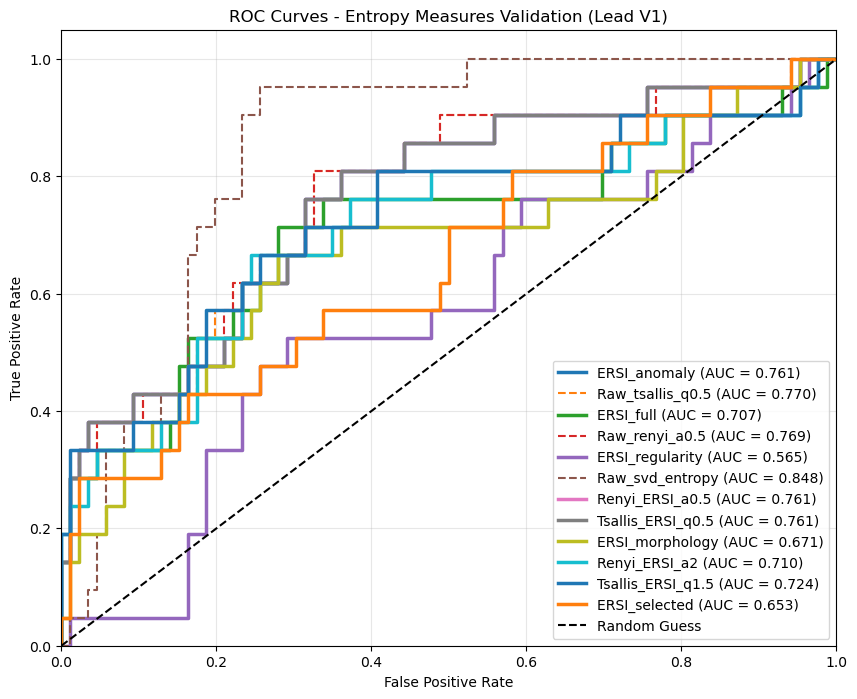

,Method,p-value,AUC,Sensitivity,Specificity
0,Raw_svd_entropy,8.232859e-07,0.848283,0.952381,0.744186
1,Raw_tsallis_q0.5,1.356546e-04,0.769657,0.809524,0.674419
2,Raw_renyi_a0.5,1.400296e-04,0.769103,0.809524,0.674419
3,ERSI_anomaly,2.170447e-04,0.761351,0.809524,0.639535
4,Tsallis_ERSI_q0.5,2.170447e-04,0.761351,0.809524,0.639535
5,Renyi_ERSI_a0.5,2.170447e-04,0.761351,0.809524,0.639535
6,Raw_shannon,4.614128e-04,0.747508,0.714286,0.744186
7,Raw_perm_entropy,8.695510e-04,0.735327,0.714286,0.755814
8,Raw_tsallis_q1.5,1.214188e-03,0.728682,0.714286,0.709302
9,Tsallis_ERSI_q1.5,1.509888e-03,0.724252,0.666667,0.744186



Running Noise Simulation Evaluation...


,Method,p-value,AUC,Sensitivity,Specificity
0,Raw_svd_entropy,6.730902e-07,0.851052,0.952381,0.755814
1,Raw_perm_entropy,9.874031e-06,0.812292,0.666667,0.860465
2,Raw_tsallis_q0.5,1.356598e-04,0.769657,0.857143,0.651163
3,Raw_renyi_a0.5,1.400349e-04,0.769103,0.857143,0.651163
4,Tsallis_ERSI_q0.5,1.400349e-04,0.769103,0.857143,0.627907
5,ERSI_anomaly,1.445426e-04,0.768549,0.857143,0.627907
6,Renyi_ERSI_a0.5,1.445426e-04,0.768549,0.857143,0.627907
7,Raw_shannon,4.752007e-04,0.746955,0.761905,0.732558
8,Tsallis_ERSI_q1.5,7.547959e-04,0.738095,0.714286,0.779070
9,Raw_tsallis_q1.5,8.218485e-04,0.736434,0.714286,0.790698


In [13]:
import numpy as np
import pandas as pd
import wfdb
import os
from sklearn.model_selection import train_test_split
from ersi.ersi_val_pipeline import ERSIPipelineValidator
from tqdm import tqdm  # for progress bars (pip install tqdm if needed)

# ==========================================
# 1. LOAD METADATA AND GET PATIENT LISTS
# ==========================================
print("Loading metadata...")
metadata = pd.read_csv('metadata.csv')

# Get lists of patient IDs by group
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()

print(f"Found {len(healthy_patients)} healthy patients, {len(brugada_patients)} Brugada patients")

# ==========================================
# 2. LOAD ECG SIGNALS (LEAD V1)
# ==========================================
def load_patient_ecg(patient_id, lead_index=6, data_dir='files'):
    """
    Load ECG signal for a single patient.
    
    Parameters:
    - patient_id: str, the patient identifier
    - lead_index: int, index of lead to extract (6 = V1 in standard 12-lead)
    - data_dir: str, base directory containing patient subfolders
    
    Returns:
    - signal: numpy array of the ECG signal for the specified lead
    """
    try:
        # Construct the path: files/patient_id/patient_id
        record_path = os.path.join(data_dir, patient_id, patient_id)
        
        # Read the WFDB record
        record = wfdb.rdrecord(record_path)
        
        # Optional: Print lead names for first patient to verify V1 index
        # Uncomment if you want to check:
        # if patient_id == healthy_patients[0]:
        #     print(f"Lead names: {record.sig_name}")
        #     print(f"Sampling frequency: {record.fs} Hz")
        
        # Extract the specified lead
        signal = record.p_signal[:, lead_index]
        
        # Basic check for signal quality
        if np.all(signal == 0) or np.isnan(signal).all():
            print(f"Warning: Patient {patient_id} lead {lead_index} has invalid signal")
            return None
            
        return signal
    except Exception as e:
        print(f"Error loading patient {patient_id}: {e}")
        return None

# Choose lead (V1 = index 6, adjust based on your data)
LEAD_V1_IDX = 6
DATA_DIRECTORY = 'files'  # Base directory containing patient folders

# Optional: Verify lead index with first patient
if len(healthy_patients) > 0:
    try:
        test_record = wfdb.rdrecord(os.path.join(DATA_DIRECTORY, healthy_patients[0], healthy_patients[0]))
        print(f"\nLead names: {test_record.sig_name}")
        print(f"V1 index: {test_record.sig_name.index('V1') if 'V1' in test_record.sig_name else 'Not found'}")
        print(f"Sampling frequency: {test_record.fs} Hz")
        # Update LEAD_V1_IDX if needed
        if 'V1' in test_record.sig_name:
            LEAD_V1_IDX = test_record.sig_name.index('V1')
    except Exception as e:
        print(f"Could not verify lead index: {e}")

print(f"\nLoading ECG signals (Lead V1, index {LEAD_V1_IDX})...")

print("Loading healthy patients...")
healthy_signals = []
for pid in tqdm(healthy_patients):
    sig = load_patient_ecg(pid, lead_index=LEAD_V1_IDX, data_dir=DATA_DIRECTORY)
    if sig is not None:
        healthy_signals.append(sig)

print("Loading Brugada patients...")
brugada_signals = []
for pid in tqdm(brugada_patients):
    sig = load_patient_ecg(pid, lead_index=LEAD_V1_IDX, data_dir=DATA_DIRECTORY)
    if sig is not None:
        brugada_signals.append(sig)

print(f"\nSuccessfully loaded {len(healthy_signals)} healthy, {len(brugada_signals)} Brugada signals")

# ==========================================
# 3. CREATE TRAINING/TEST SETS
# ==========================================
if len(healthy_signals) == 0 or len(brugada_signals) == 0:
    print("\nERROR: No signals loaded. Check file paths and data directory.")
    # Exit or use dummy data for testing
    use_dummy = True
else:
    use_dummy = False

if use_dummy:
    print("\nUsing dummy data for testing...")
    np.random.seed(42)
    all_patient_signals = [np.random.randn(5000) for _ in range(10)]
    all_patient_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
else:
    # Combine all signals and create labels
    all_patient_signals = healthy_signals + brugada_signals
    all_patient_labels = [0] * len(healthy_signals) + [1] * len(brugada_signals)

print(f"\nTotal patients: {len(all_patient_signals)}")
print(f"Class distribution: {np.bincount(all_patient_labels)}")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    all_patient_signals,
    all_patient_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_patient_labels
)

print(f"Split complete: {len(X_train)} Train patients, {len(X_test)} Test patients.")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Test distribution: {np.bincount(y_test)}")

# Get sampling frequency from the first loaded record
if not use_dummy and len(healthy_signals) > 0:
    try:
        test_record = wfdb.rdrecord(os.path.join(DATA_DIRECTORY, healthy_patients[0], healthy_patients[0]))
        fs = test_record.fs
        print(f"Using sampling frequency: {fs} Hz")
    except:
        fs = 500  # default fallback
        print(f"Using default sampling frequency: {fs} Hz")
else:
    fs = 500
    print(f"Using default sampling frequency: {fs} Hz")

# ==========================================
# 4. RUN ERSI VALIDATION PIPELINE
# ==========================================
# Initialize validator
validator = ERSIPipelineValidator(fs=fs, window_sec=5.0, step_sec=2.5)

# Feature selection on training set
print("\nExtracting features for Training Set...")
patient_dfs_train = validator.extract_features(X_train)

print("Running Feature Selection...")
selected_features = validator.feature_selection(patient_dfs_train, y_train, top_k=3)
print(f"Selected features: {selected_features}")

# Evaluate on test set
print("\nExtracting features for Test Set...")
patient_dfs_test = validator.extract_features(X_test)

print("Computing ERSI modes...")
df_results_test = validator.compute_ersi_modes(patient_dfs_test, selected_features)

print("Evaluating ERSI...")
df_eval_test = validator.evaluate(df_results_test, y_test, plot=True, title_suffix="(Lead V1)")

# Display results
from IPython.display import display
display(df_eval_test)

# Optional: noise simulation
print("\nRunning Noise Simulation Evaluation...")
df_eval_noisy = validator.simulate_noise_evaluation(X_test, y_test, selected_features, noise_level=0.1)
display(df_eval_noisy)

In [14]:
# Import the VCG function
from ecg_pipeline_features import combine_to_vcg

# Create a DataFrame of all your leads first so NeuroKit2 knows which is which
leads_dict = {lead_names[i]: signals[:, i] for i in range(len(lead_names))}
all_leads_df = pd.DataFrame(leads_dict)

# Run the VCG combination pipeline
vcg_df = combine_to_vcg(all_leads_df)

# The output will be a DataFrame with 'VCG_x', 'VCG_y', 'VCG_z'
display(vcg_df.head())


,VCG_x,VCG_y,VCG_z
0,0.07674,-0.26675,-0.04142
1,0.27696,-0.03731,-0.12434
2,0.75408,0.00906,-0.34213
3,0.89751,0.26926,-0.40671
4,0.40706,0.43297,-0.19312


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from ersi.ersi_val_pipeline import ERSIPipelineValidator

# ==========================================
# 1. PREPARE THE DATA (Lead V1 extraction)
# ==========================================
print("Extracting Lead V1 signals...")
# Assuming 'signals' is the shape (samples, leads) from your previous wfdb cell
# Lead names are typically (I, II, III, aVR, aVL, aVF, V1–V6)
# V1 is usually at index 6 in standard 12-lead
lead_v1_idx = 6 

# IMPORTANT: You need a list of signals from multiple patients here. 
# For demonstration purposes, let's pretend we have a list of patient signals `all_patient_signals` 
# and a list of labels `all_patient_labels` (1 = Brugada, 0 = Control).
# 
# Example placeholder (REPLACE WITH YOUR ACTUAL PATIENT LOOP/LOADER):
#all_patient_signals = [patient_1_v1, patient_2_v1, patient_3_v1, ...]
#all_patient_labels = [1, 0, 1, ...]
# Run benchmark across two subsets
# First, load the metadata to find which patients are Healthy (Normal) vs Brugada
import pandas as pd
import wfdb
import os
metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []


# --- DUMMY DATA FOR NOTEBOOK TESTING ---
# If you don't have the list loaded yet, this will let the cell run to show it works:
#np.random.seed(42)
#all_patient_signals = [np.random.randn(5000) for _ in range(10)] # 10 dummy patients
#all_patient_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]              # 10 dummy labels
# ---------------------------------------

# ==========================================
# 2. TRAIN / TEST SPLIT (70% / 30%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    all_patient_signals, 
    all_patient_labels, 
    test_size=0.30, 
    random_state=42,
    stratify=all_patient_labels # Ensures balanced Brugada/Control in train and test
)
print(f"Split complete: {len(X_train)} Train patients, {len(X_test)} Test patients.")

# ==========================================
# 3. INITIALIZE ERSI VALIDATOR
# ==========================================
# fs=500 is common for PhysioNet, adjust to your dataset's actual sampling frequency
validator = ERSIPipelineValidator(fs=500, window_sec=5.0, step_sec=2.5)

# ==========================================
# 4. FEATURE SELECTION ON TRAINING SET
# ==========================================
print("\nExtracting features for Training Set...")
patient_dfs_train = validator.extract_features(X_train)

print("Running Feature Selection (Morphology Top 3)...")
selected_features = validator.feature_selection(patient_dfs_train, y_train, top_k=3)

# ==========================================
# 5. COMPUTE & EVALUATE ON TEST SET
# ==========================================
print("\nExtracting features for Test Set...")
patient_dfs_test = validator.extract_features(X_test)

print("Computing ERSI modes for Test Set...")
df_results_test = validator.compute_ersi_modes(patient_dfs_test, selected_features)

print("Evaluating ERSI (Generating Table & ROC Curve Plots)...")
# Plot=True will generate the matplotlib ROC curves right here in the notebook
df_eval_test = validator.evaluate(df_results_test, y_test, plot=True, title_suffix="(Lead V1)")

display(df_eval_test)

# ==========================================
# 6. OPTIONAL: NOISE SIMULATION TEST
# ==========================================
print("\nRunning Noise Simulation Evaluation (10% Gaussian Noise)...")
df_eval_noisy = validator.simulate_noise_evaluation(X_test, y_test, selected_features, noise_level=0.1)
display(df_eval_noisy)


Extracting Lead V1 signals...


NameError: name 'patient_1_v1' is not defined